## Preamble

In [1]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

c=299 #m/μs

In [2]:
from scipy.interpolate import RegularGridInterpolator

def resample2d(data, ni1, ni2, di1, di2, no1, no2, do1, do2):
    # 1. Reconstruct original physical coordinate axes
    xi1 = np.arange(ni1) * di1
    xi2 = np.arange(ni2) * di2
    
    # 2. Create the interpolator function from the original grid
    # bounds_error=False and fill_value=None allows extrapolation if grids do not align perfectly
    interp_func = RegularGridInterpolator((xi1, xi2), data, method='linear', 
                                         bounds_error=False, fill_value=None)
    
    # 3. Generate target physical coordinate axes
    xo1 = np.arange(no1) * do1
    xo2 = np.arange(no2) * do2
    
    # 4. Create a 2D mesh grid of target points for evaluation
    # 'ij' indexing matches the shape layout of the matrix (rows, columns)
    XO1, XO2 = np.meshgrid(xo1, xo2, indexing='ij')
    
    # 5. Reshape to a list of (x1, x2) coordinate pairs for the interpolator
    target_points = np.stack([XO1.ravel(), XO2.ravel()], axis=-1)
    
    # 6. Evaluate and reshape back to the target 2D shape
    resampled_array = interp_func(target_points).reshape(no1, no2)
    
    return resampled_array

In [46]:
def read(filename,n=(1,nt)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(1,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=17):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[24:24+nz,24:24+nx,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/FWI',setup='setup',np=1,nthreads=8,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

In [44]:
ε_r=12; μ_r=1; σ=0.006

v = c/np.sqrt(ε_r*μ_r)
print('v =',v) #86 m/μs

fpeak = 400 #MHz

λmin = v/fpeak/2
print('λmin =',λmin) #0.108 m

h=0.02 #m

nz=201; nx=201
nzsnap=nz+48
nxsnap=nx+48
nsnap=51
print(f'length = {(nz-1)*h} m')

dt_CFL = 0.6*h/v
print('dt_CFL =',dt_CFL) #μs
dt = 0.0001 #μs

nt = 1000 #T=0.1 μs
t=np.arange(0,nt*dt,dt)

v = 86.31386524384905
λmin = 0.10789233155481132
length = 4.0 m
dt_CFL = 0.000139027489570746


In [51]:
%%writefile setup_default

MODEL_SIZE              '201   201   1'
MODEL_SPACING           '0.02 0.02  1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'model'
MODEL_ATTRIBUTES        'eps_r mu_r sgma'
NAIRL                    0

ACQUI_GEOMETRY          spread
FS                      '1  2  0'
FR                      '1  2  0'
DR                      '0  0  0'
NR                       1

IF_HICKS                 F

SCOMP                    Ey
RCOMP                    Ey

NT                       1000
DT                       0.0001
WAVELET_TYPE             ricker
FPEAK                    400

SNAPSHOT                'Hx Hz Ey'

IF_USE_CHECKPOINT        F

Writing setup_default


## Background model

In [52]:
eps_r = ε_r*np.ones((nz,nx)); eps_r.T.astype('float32').tofile('eps_r')
mu_r  = μ_r*np.ones((nz,nx));  mu_r.T.astype('float32').tofile('mu_r')
sgma  =   σ*np.ones((nz,nx));  sgma.T.astype('float32').tofile('sgma')

!cat eps_r mu_r sgma > model

In [53]:
!cp setup_default setup
!echo "DIR_OUT   res_bkgr" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_ScatteringPatterns
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2176512 Jun 19 22:44 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: cfd890f
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/19/2026
System time: 22:55:05
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_bkgr
 Output directory:res_bkgr/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0

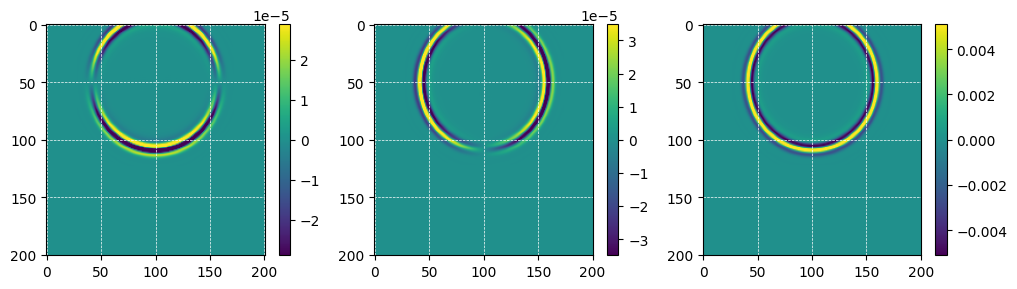

In [55]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_bkgr/snap_fld_u%Hx',i=8),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_bkgr/snap_fld_u%Hz',i=8),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_bkgr/snap_fld_u%Ey',i=8),perc=98)

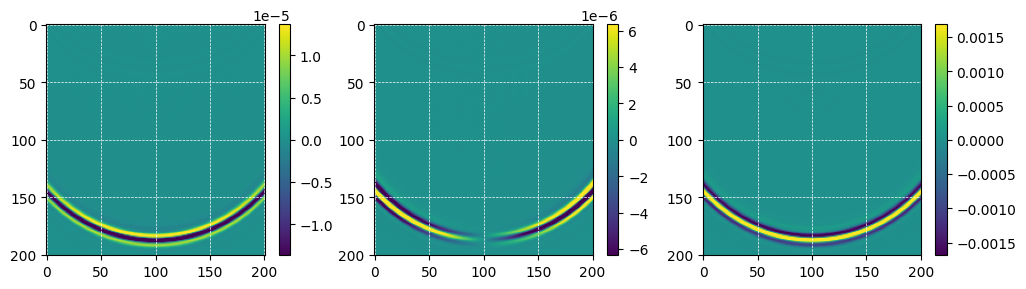

In [56]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_bkgr/snap_fld_u%Hx'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_bkgr/snap_fld_u%Hz'),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_bkgr/snap_fld_u%Ey'),perc=98)

## Perturb

### eps_r

In [71]:
eps_r = ε_r*np.ones((nz,nx)); 
eps_r[nz//2-1:nz//2+1,nx//2-1:nx//2+1]=24; eps_r.T.astype('float32').tofile('eps_r')
mu_r  = μ_r*np.ones((nz,nx));  mu_r.T.astype('float32').tofile('mu_r')
sgma  =   σ*np.ones((nz,nx));  sgma.T.astype('float32').tofile('sgma')

!cat eps_r mu_r sgma > model

In [72]:
!cp setup_default setup
!echo "DIR_OUT   res_pert_eps" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_ScatteringPatterns
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2176512 Jun 19 22:44 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: cfd890f
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/19/2026
System time: 23:00:35
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_pert_eps
 Output directory:res_pert_eps/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -

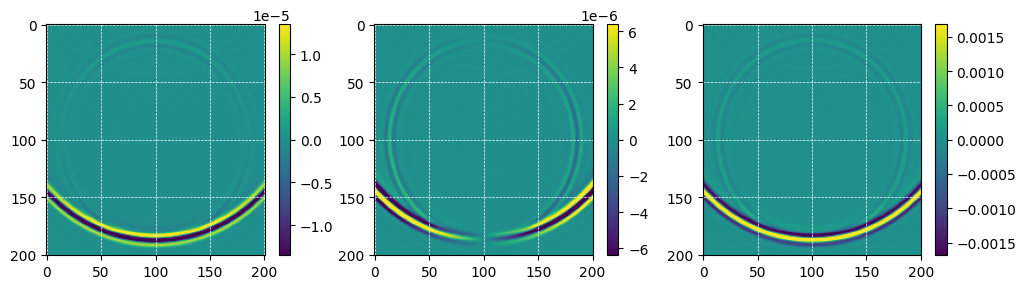

In [73]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_pert_eps/snap_fld_u%Hx'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_pert_eps/snap_fld_u%Hz'),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_pert_eps/snap_fld_u%Ey'),perc=98)

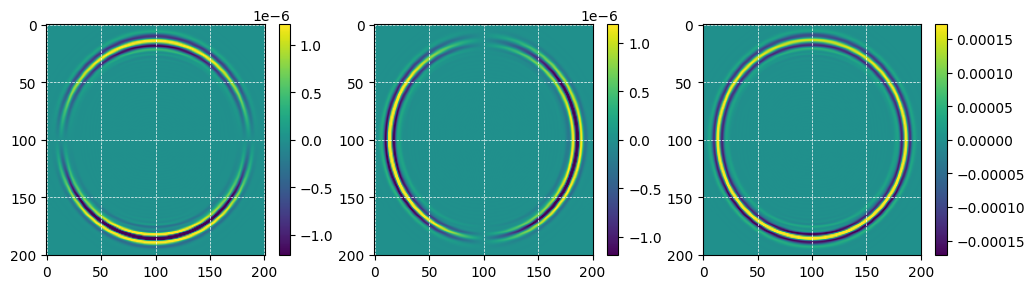

In [74]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_pert_eps/snap_fld_u%Hx')-read_snap('res_bkgr/snap_fld_u%Hx'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_pert_eps/snap_fld_u%Hz')-read_snap('res_bkgr/snap_fld_u%Hz'),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_pert_eps/snap_fld_u%Ey')-read_snap('res_bkgr/snap_fld_u%Ey'),perc=98)

### mu_r

In [75]:
eps_r = ε_r*np.ones((nz,nx)); eps_r.T.astype('float32').tofile('eps_r')
mu_r  = μ_r*np.ones((nz,nx)); 
mu_r[nz//2-1:nz//2+1,nx//2-1:nx//2+1]=1.5; mu_r.T.astype('float32').tofile('mu_r')
sgma  =   σ*np.ones((nz,nx)); sgma.T.astype('float32').tofile('sgma')

!cat eps_r mu_r sgma > model

In [76]:
!cp setup_default setup
!echo "DIR_OUT   res_pert_mu" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_ScatteringPatterns
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2176512 Jun 19 22:44 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: cfd890f
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/19/2026
System time: 23:01:33
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_pert_mu
 Output directory:res_pert_mu/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> 

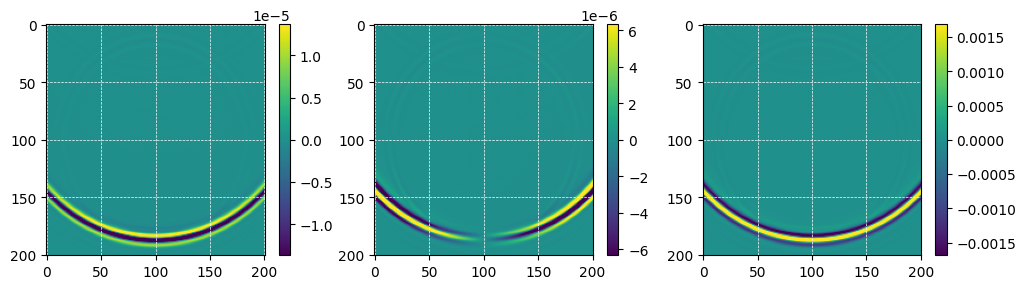

In [77]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_pert_mu/snap_fld_u%Hx'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_pert_mu/snap_fld_u%Hz'),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_pert_mu/snap_fld_u%Ey'),perc=98)

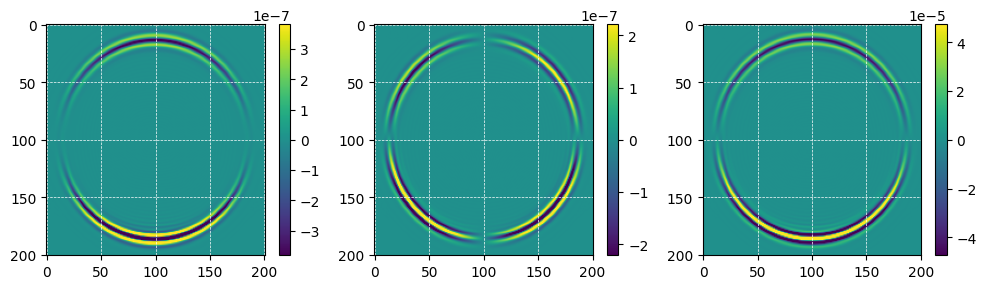

In [78]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_pert_mu/snap_fld_u%Hx')-read_snap('res_bkgr/snap_fld_u%Hx'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_pert_mu/snap_fld_u%Hz')-read_snap('res_bkgr/snap_fld_u%Hz'),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_pert_mu/snap_fld_u%Ey')-read_snap('res_bkgr/snap_fld_u%Ey'),perc=98)

### sigma

In [79]:
eps_r = ε_r*np.ones((nz,nx)); eps_r.T.astype('float32').tofile('eps_r')
mu_r  = μ_r*np.ones((nz,nx)); mu_r.T.astype('float32').tofile('mu_r')
sgma  =   σ*np.ones((nz,nx)); 
sgma[nz//2-1:nz//2+1,nx//2-1:nx//2+1]=2*σ; sgma.T.astype('float32').tofile('sgma')

!cat eps_r mu_r sgma > model

In [80]:
!cp setup_default setup
!echo "DIR_OUT   res_pert_sgma" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_ScatteringPatterns
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2176512 Jun 19 22:44 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: cfd890f
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/19/2026
System time: 23:03:24
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_pert_sgma
 Output directory:res_pert_sgma/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
  

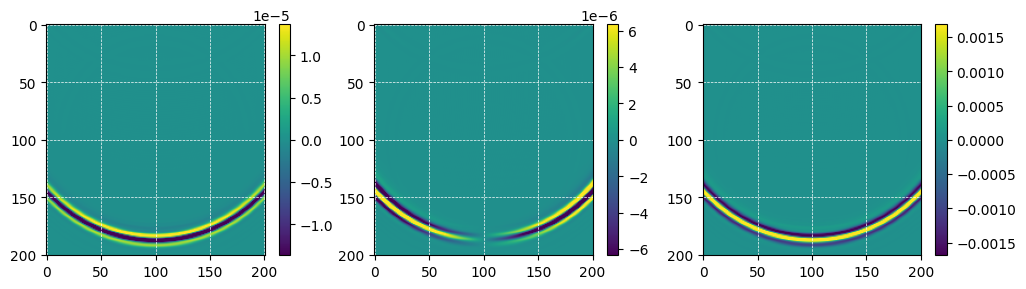

In [81]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_pert_sgma/snap_fld_u%Hx'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_pert_sgma/snap_fld_u%Hz'),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_pert_sgma/snap_fld_u%Ey'),perc=98)

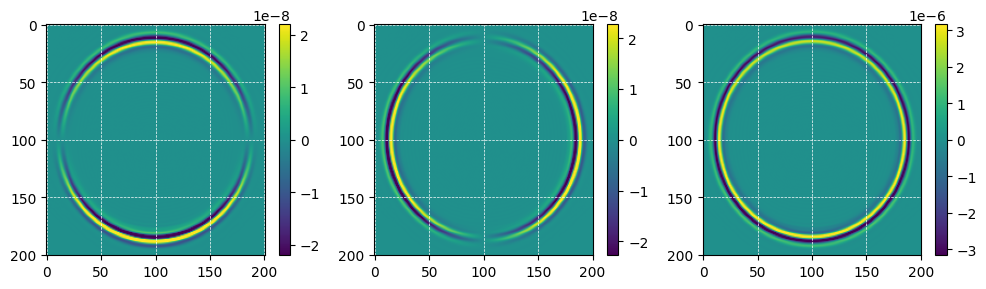

In [82]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_pert_sgma/snap_fld_u%Hx')-read_snap('res_bkgr/snap_fld_u%Hx'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_pert_sgma/snap_fld_u%Hz')-read_snap('res_bkgr/snap_fld_u%Hz'),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_pert_sgma/snap_fld_u%Ey')-read_snap('res_bkgr/snap_fld_u%Ey'),perc=98)